In [1]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.metrics import mean_absolute_error

In [2]:
#df = pd.read_csv('D:\municipality_bus_utilization.csv', header=0, index_col=0 ,parse_dates=[0])
df = pd.read_csv('D:\municipality_bus_utilization.csv', header=0,parse_dates=[0])

In [3]:
df.head(5)

,timestamp,municipality_id,usage,total_capacity
0,2017-04-06 07:59:00,9,454,1332
1,2017-04-06 07:59:00,8,556,2947
2,2017-04-06 07:59:00,4,1090,3893
3,2017-04-06 07:59:00,0,204,2813
4,2017-04-06 07:59:00,7,718,2019


In [4]:
#df.isnull()
df.isnull().sum()       #Apparently the dataset does not have any missing data

timestamp          0
municipality_id    0
usage              0
total_capacity     0
dtype: int64

In [5]:
del df['total_capacity']   #Dropping Total Capacity column

In [6]:
#Hourly Data
hourlyDF  =  df.groupby(['municipality_id', pd.Grouper(key='timestamp', freq='H')])['usage'].max()
hourlyDF = hourlyDF.reset_index()
#hourlyDF.set_index('timestamp', inplace=True)
hourlyDF

,municipality_id,timestamp,usage
0,0,2017-01-07 08:00:00,228
1,0,2017-01-07 09:00:00,360
2,0,2017-01-07 10:00:00,446
3,0,2017-01-07 11:00:00,509
4,0,2017-01-07 12:00:00,529
...,...,...,...
6735,9,2017-12-08 12:00:00,869
6736,9,2017-12-08 13:00:00,868
6737,9,2017-12-08 14:00:00,849
6738,9,2017-12-08 15:00:00,798


In [7]:
hourlyDF.shape

(6740, 3)

In [8]:
hourlyDF['u'] = hourlyDF['usage'].shift(1)

In [9]:
from datetime import datetime
training_data=hourlyDF[hourlyDF.timestamp<datetime(2017, 8, 5)]
testing_data=hourlyDF[hourlyDF.timestamp>datetime(2017, 8, 5)]

In [10]:
print(training_data.shape)
print(testing_data.shape)

(4690, 4)
(2050, 4)


In [11]:
training_dataMP0 = training_data[(training_data['municipality_id'] == 0)]
testing_dataMP0 = testing_data[(testing_data['municipality_id'] == 0)]

training_dataMP1 = training_data[(training_data['municipality_id'] == 1)]
testing_dataMP1 = testing_data[(testing_data['municipality_id'] == 1)]

training_dataMP2 = training_data[(training_data['municipality_id'] == 2)]
testing_dataMP2 = testing_data[(testing_data['municipality_id'] == 2)]

training_dataMP3 = training_data[(training_data['municipality_id'] == 3)]
testing_dataMP3 = testing_data[(testing_data['municipality_id'] == 3)]

training_dataMP4 = training_data[(training_data['municipality_id'] == 4)]
testing_dataMP4 = testing_data[(testing_data['municipality_id'] == 4)]

training_dataMP5 = training_data[(training_data['municipality_id'] == 5)]
testing_dataMP5 = testing_data[(testing_data['municipality_id'] == 5)]

training_dataMP6 = training_data[(training_data['municipality_id'] == 6)]
testing_dataMP6 = testing_data[(testing_data['municipality_id'] == 6)]

training_dataMP7 = training_data[(training_data['municipality_id'] == 7)]
testing_dataMP7 = testing_data[(testing_data['municipality_id'] == 7)]

training_dataMP8 = training_data[(training_data['municipality_id'] == 8)]
testing_dataMP8 = testing_data[(testing_data['municipality_id'] == 8)]

training_dataMP9 = training_data[(training_data['municipality_id'] == 9)]
testing_dataMP9 = testing_data[(testing_data['municipality_id'] == 9)]

### Baseline Model (Naive Forecast Model)

In [12]:
training_dataMP0_X, training_dataMP0_y = training_dataMP0['u'], training_dataMP0['usage']
testing_dataMP0_X, testing_dataMP0_y = testing_dataMP0['u'], testing_dataMP0['usage']

training_dataMP1_X, training_dataMP1_y = training_dataMP1['u'], training_dataMP1['usage']
testing_dataMP1_X, testing_dataMP1_y = testing_dataMP1['u'], testing_dataMP1['usage']

training_dataMP2_X, training_dataMP2_y = training_dataMP2['u'], training_dataMP2['usage']
testing_dataMP2_X, testing_dataMP2_y = testing_dataMP2['u'], testing_dataMP2['usage']

training_dataMP3_X, training_dataMP3_y = training_dataMP3['u'], training_dataMP3['usage']
testing_dataMP3_X, testing_dataMP3_y = testing_dataMP3['u'], testing_dataMP3['usage']

training_dataMP4_X, training_dataMP4_y = training_dataMP4['u'], training_dataMP4['usage']
testing_dataMP4_X, testing_dataMP4_y = testing_dataMP4['u'], testing_dataMP4['usage']

training_dataMP5_X, training_dataMP5_y = training_dataMP5['u'], training_dataMP5['usage']
testing_dataMP5_X, testing_dataMP5_y = testing_dataMP5['u'], testing_dataMP5['usage']

training_dataMP6_X, training_dataMP6_y = training_dataMP6['u'], training_dataMP6['usage']
testing_dataMP6_X, testing_dataMP6_y = testing_dataMP6['u'], testing_dataMP6['usage']

training_dataMP7_X, training_dataMP7_y = training_dataMP7['u'], training_dataMP7['usage']
testing_dataMP7_X, testing_dataMP7_y = testing_dataMP7['u'], testing_dataMP7['usage']

training_dataMP8_X, training_dataMP8_y = training_dataMP8['u'], training_dataMP8['usage']
testing_dataMP8_X, testing_dataMP8_y = testing_dataMP8['u'], testing_dataMP8['usage']

training_dataMP9_X, training_dataMP9_y = training_dataMP9['u'], training_dataMP9['usage']
testing_dataMP9_X, testing_dataMP9_y = testing_dataMP9['u'], testing_dataMP9['usage']

In [13]:
predictionsMP0 = testing_dataMP0_X.copy()
predictionsMP1 = testing_dataMP1_X.copy()
predictionsMP2 = testing_dataMP2_X.copy()
predictionsMP3 = testing_dataMP3_X.copy()
predictionsMP4 = testing_dataMP4_X.copy()
predictionsMP5 = testing_dataMP5_X.copy()
predictionsMP6 = testing_dataMP6_X.copy()
predictionsMP7 = testing_dataMP7_X.copy()
predictionsMP8 = testing_dataMP8_X.copy()
predictionsMP9 = testing_dataMP9_X.copy()

In [14]:
MSEMP0 = mean_squared_error(testing_dataMP0_y, predictionsMP0)
print("MSE for Municipality 0:", MSEMP0)

MSEMP1 = mean_squared_error(testing_dataMP1_y, predictionsMP0)
print("MSE for Municipality 1:", MSEMP1)

MSEMP2 = mean_squared_error(testing_dataMP2_y, predictionsMP0)
print("MSE for Municipality 2:", MSEMP2)

MSEMP3 = mean_squared_error(testing_dataMP3_y, predictionsMP0)
print("MSE for Municipality 3:", MSEMP3)

MSEMP4 = mean_squared_error(testing_dataMP4_y, predictionsMP0)
print("MSE for Municipality 4:", MSEMP4)

MSEMP5 = mean_squared_error(testing_dataMP5_y, predictionsMP0)
print("MSE for Municipality 5:", MSEMP5)

MSEMP6 = mean_squared_error(testing_dataMP6_y, predictionsMP0)
print("MSE for Municipality 6:", MSEMP6)

MSEMP7 = mean_squared_error(testing_dataMP7_y, predictionsMP0)
print("MSE for Municipality 7:", MSEMP7)

MSEMP8 = mean_squared_error(testing_dataMP8_y, predictionsMP0)
print("MSE for Municipality 8:", MSEMP8)

MSEMP9 = mean_squared_error(testing_dataMP9_y, predictionsMP0)
print("MSE for Municipality 9:", MSEMP9)

MSE for Municipality 0: 18967.780487804877
MSE for Municipality 1: 146843.97073170732
MSE for Municipality 2: 89283.99512195121
MSE for Municipality 3: 436515.5414634146
MSE for Municipality 4: 3893077.907317073
MSE for Municipality 5: 247975.18536585366
MSE for Municipality 6: 260132.4243902439
MSE for Municipality 7: 475427.4
MSE for Municipality 8: 313760.99024390243
MSE for Municipality 9: 82921.89268292683


### ARIMA Model 

In [15]:
del hourlyDF['u']

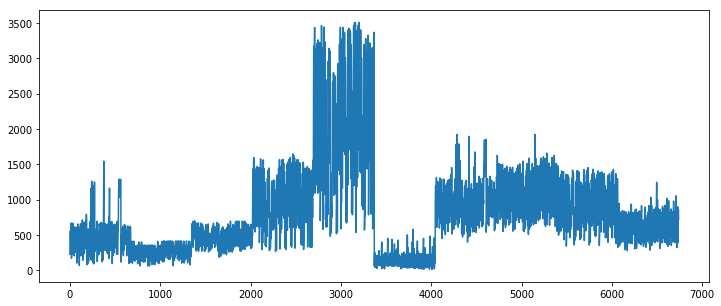

In [16]:
hourlyDF['usage'].plot(figsize=(12,5))

In [17]:
from statsmodels.tsa.stattools import adfuller
def ad_test(dataset):
     dftest = adfuller(dataset, autolag = 'AIC')
     print("1. ADF : ",dftest[0])
     print("2. P-Value : ", dftest[1])
     print("3. Num Of Lags : ", dftest[2])
     print("4. Num Of Observations Used For ADF Regression:",      dftest[3])
     print("5. Critical Values :")
     for key, val in dftest[4].items():
         print("\t",key, ": ", val)

In [18]:
ad_test(df['usage'])   #Checking the value of P: it's very less so we can confirm that the trend is stationary

1. ADF :  -11.633527571168388
2. P-Value :  2.2329301100747135e-21
3. Num Of Lags :  41
4. Num Of Observations Used For ADF Regression: 13028
5. Critical Values :
	 1% :  -3.43085204090602
	 5% :  -2.861761877895934
	 10% :  -2.56688810067643


In [19]:
from pmdarima import auto_arima
stepwise_fit = auto_arima(df['usage'], trace=True, suppress_warnings=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=206519.474, Time=11.55 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=215939.771, Time=0.20 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=212309.604, Time=0.46 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=206888.757, Time=2.13 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=215937.771, Time=0.13 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=206539.021, Time=13.76 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=206801.114, Time=8.81 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=206574.821, Time=17.26 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=206898.375, Time=10.82 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=206861.732, Time=6.21 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=206520.672, Time=18.17 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=206742.277, Time=12.20 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=22.39 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=206517.468, Time=5.14 sec
 ARIM

In [26]:
import statsmodels.api as sm

In [21]:
training_data=hourlyDF[hourlyDF.timestamp<datetime(2017, 8, 5)]
testing_data=hourlyDF[hourlyDF.timestamp>datetime(2017, 8, 5)]

In [23]:
print(training_data.shape)
print(testing_data.shape)

(4690, 3)
(2050, 3)


In [24]:
training_dataMP0 = training_data[(training_data['municipality_id'] == 0)]
testing_dataMP0 = testing_data[(testing_data['municipality_id'] == 0)]

training_dataMP1 = training_data[(training_data['municipality_id'] == 1)]
testing_dataMP1 = testing_data[(testing_data['municipality_id'] == 1)]

training_dataMP2 = training_data[(training_data['municipality_id'] == 2)]
testing_dataMP2 = testing_data[(testing_data['municipality_id'] == 2)]

training_dataMP3 = training_data[(training_data['municipality_id'] == 3)]
testing_dataMP3 = testing_data[(testing_data['municipality_id'] == 3)]

training_dataMP4 = training_data[(training_data['municipality_id'] == 4)]
testing_dataMP4 = testing_data[(testing_data['municipality_id'] == 4)]

training_dataMP5 = training_data[(training_data['municipality_id'] == 5)]
testing_dataMP5 = testing_data[(testing_data['municipality_id'] == 5)]

training_dataMP6 = training_data[(training_data['municipality_id'] == 6)]
testing_dataMP6 = testing_data[(testing_data['municipality_id'] == 6)]

training_dataMP7 = training_data[(training_data['municipality_id'] == 7)]
testing_dataMP7 = testing_data[(testing_data['municipality_id'] == 7)]

training_dataMP8 = training_data[(training_data['municipality_id'] == 8)]
testing_dataMP8 = testing_data[(testing_data['municipality_id'] == 8)]

training_dataMP9 = training_data[(training_data['municipality_id'] == 9)]
testing_dataMP9 = testing_data[(testing_data['municipality_id'] == 9)]

### ARIMA Model for Municipality 0

In [42]:
model0=sm.tsa.arima.ARIMA(training_dataMP0['usage'],order=(2,1,2))
model0=model0.fit()
model0.summary()

D:\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
D:\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  usage   No. Observations:                  469
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -3004.816
Date:                Fri, 13 May 2022   AIC                           6019.632
Time:                        17:18:34   BIC                           6040.374
Sample:                             0   HQIC                          6027.794
                                - 469                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.3960      0.058     24.106      0.000       1.282       1.509
ar.L2         -0.7289      0.044    -16.443      0.000      -0.816      -0.642
ma.L1         -1.5105      0.071    -21.331      0.000      -1.649      -1.372
ma.L2          0.5933      0.070      8.532      0.000       0.457       0.730
sigma2      2.203e+04    839.353     26.241      0.000    2.04e+04    2.37e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):              1605.73
Prob(Q):                              0.73   Prob(JB):                         0.00
Heteroskedasticity (H):               2.36   Skew:                            -1.86
Prob(H) (two-sided):                  0.00   Kurtosis:                        11.28
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Mean Squared Error: 276.02607042293675


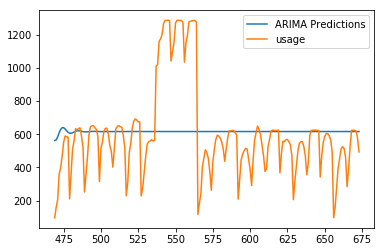

In [76]:
start=len(training_dataMP0)
end=len(training_dataMP0)+len(testing_dataMP0)-1
predMP0=model0.predict(start=start,end=end,typ='levels').rename('ARIMA Predictions')
predMP0.plot(legend=True)
testing_dataMP0['usage'].plot(legend=True)


testing_dataMP0['usage'].mean()
rmseMP0=sqrt(mean_squared_error(predMP0,testing_dataMP0['usage']))
print("Mean Squared Error:", rmseMP0)

### ARIMA Model for Municipality 1

In [47]:
model1=sm.tsa.arima.ARIMA(training_dataMP1['usage'],order=(2,1,2))
model1=model1.fit()
model1.summary()

D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
D:\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-in

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  usage   No. Observations:                  469
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -2568.463
Date:                Fri, 13 May 2022   AIC                           5146.926
Time:                        17:23:06   BIC                           5167.668
Sample:                             0   HQIC                          5155.088
                                - 469                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.3587      0.077     17.652      0.000       1.208       1.510
ar.L2         -0.7019      0.047    -15.070      0.000      -0.793      -0.611
ma.L1         -1.5767      0.084    -18.770      0.000      -1.741      -1.412
ma.L2          0.5946      0.083      7.163      0.000       0.432       0.757
sigma2      3400.1667    185.466     18.333      0.000    3036.660    3763.674
===================================================================================
Ljung-Box (L1) (Q):                   0.39   Jarque-Bera (JB):               486.36
Prob(Q):                              0.53   Prob(JB):                         0.00
Heteroskedasticity (H):               1.03   Skew:                            -1.68
Prob(H) (two-sided):                  0.87   Kurtosis:                         6.70
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Mean Squared Error: 98.43047384715516


D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:843: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  data=self.data,


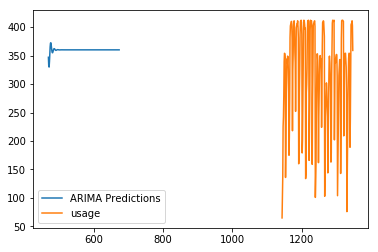

In [77]:
start=len(training_dataMP1)
end=len(training_dataMP1)+len(testing_dataMP1)-1
predMP1=model1.predict(start=start,end=end,typ='levels').rename('ARIMA Predictions')
predMP1.plot(legend=True)
testing_dataMP1['usage'].plot(legend=True)

testing_dataMP1['usage'].mean()
rmseMP1=sqrt(mean_squared_error(predMP1,testing_dataMP1['usage']))
print("Mean Squared Error:", rmseMP1)

### ARIMA Model for Municipality 2

In [48]:
model2=sm.tsa.arima.ARIMA(training_dataMP2['usage'],order=(2,1,2))
model2=model2.fit()
model2.summary()

D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
D:\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-in

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  usage   No. Observations:                  469
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -2701.308
Date:                Fri, 13 May 2022   AIC                           5412.616
Time:                        17:23:11   BIC                           5433.358
Sample:                             0   HQIC                          5420.778
                                - 469                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3693      0.037      9.984      0.000       0.297       0.442
ar.L2         -0.9014      0.034    -26.749      0.000      -0.967      -0.835
ma.L1         -0.2009      0.033     -6.058      0.000      -0.266      -0.136
ma.L2          0.9101      0.031     29.736      0.000       0.850       0.970
sigma2      6024.2040    340.064     17.715      0.000    5357.691    6690.717
===================================================================================
Ljung-Box (L1) (Q):                   3.74   Jarque-Bera (JB):               111.02
Prob(Q):                              0.05   Prob(JB):                         0.00
Heteroskedasticity (H):               1.37   Skew:                            -0.91
Prob(H) (two-sided):                  0.05   Kurtosis:                         4.54
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Mean Squared Error: 121.52890324472807


D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:843: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  data=self.data,


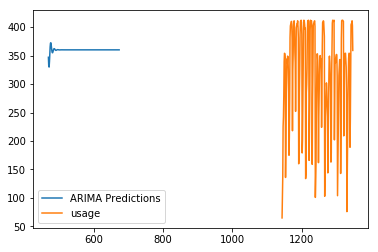

In [78]:
start=len(training_dataMP2)
end=len(training_dataMP2)+len(testing_dataMP2)-1
predMP2=model2.predict(start=start,end=end,typ='levels').rename('ARIMA Predictions')
predMP2.plot(legend=True)
testing_dataMP2['usage'].plot(legend=True)

testing_dataMP2['usage'].mean()
rmseMP2=sqrt(mean_squared_error(predMP2,testing_dataMP2['usage']))
print("Mean Squared Error:", rmseMP2)

### ARIMA Model  for Municipality 3

In [49]:
model3=sm.tsa.arima.ARIMA(training_dataMP3['usage'],order=(2,1,2))
model3=model3.fit()
model3.summary()

D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
D:\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-in

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  usage   No. Observations:                  469
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -3165.630
Date:                Fri, 13 May 2022   AIC                           6341.260
Time:                        17:23:15   BIC                           6362.002
Sample:                             0   HQIC                          6349.422
                                - 469                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.4333      0.094     15.186      0.000       1.248       1.618
ar.L2         -0.7561      0.067    -11.240      0.000      -0.888      -0.624
ma.L1         -1.3811      0.121    -11.441      0.000      -1.618      -1.144
ma.L2          0.5414      0.103      5.271      0.000       0.340       0.743
sigma2      4.386e+04   2119.865     20.691      0.000    3.97e+04     4.8e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.15   Jarque-Bera (JB):               399.86
Prob(Q):                              0.70   Prob(JB):                         0.00
Heteroskedasticity (H):               1.16   Skew:                            -1.25
Prob(H) (two-sided):                  0.35   Kurtosis:                         6.77
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [66]:
start=len(training_dataMP3)
end=len(training_dataMP3)+len(testing_dataMP3)-1
predMP3=model3.predict(start=start,end=end,typ='levels').rename('ARIMA Predictions')
predMP3.plot(legend=True)
testing_dataMP3['usage'].plot(legend=True)

testing_dataMP3['usage'].mean()
rmseMP3=sqrt(mean_squared_error(predMP3,testing_dataMP3['usage']))
print("Mean Squared Error:", rmseMP3)

Mean Squared Error: 466.22586287038445


### ARIMA Model Training for Municipality 4

In [50]:
model4=sm.tsa.arima.ARIMA(training_dataMP4['usage'],order=(2,1,2))
model4=model4.fit()
model4.summary()

D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
D:\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-in

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  usage   No. Observations:                  469
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -3547.719
Date:                Fri, 13 May 2022   AIC                           7105.439
Time:                        17:23:18   BIC                           7126.181
Sample:                             0   HQIC                          7113.601
                                - 469                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0619      0.196      5.421      0.000       0.678       1.446
ar.L2         -0.2916      0.168     -1.738      0.082      -0.620       0.037
ma.L1         -0.9962      0.215     -4.643      0.000      -1.417      -0.576
ma.L2          0.0046      0.214      0.022      0.983      -0.415       0.425
sigma2      2.237e+05   9944.288     22.499      0.000    2.04e+05    2.43e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               300.41
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):               0.96   Skew:                            -1.03
Prob(H) (two-sided):                  0.80   Kurtosis:                         6.35
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Mean Squared Error: 880.3669840353027


D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:843: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  data=self.data,


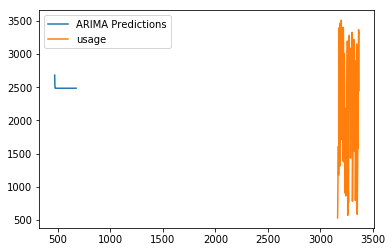

In [79]:
start=len(training_dataMP4)
end=len(training_dataMP4)+len(testing_dataMP4)-1
predMP4=model4.predict(start=start,end=end,typ='levels').rename('ARIMA Predictions')
predMP4.plot(legend=True)
testing_dataMP4['usage'].plot(legend=True)

testing_dataMP4['usage'].mean()
rmseMP4=sqrt(mean_squared_error(predMP4,testing_dataMP4['usage']))
print("Mean Squared Error:", rmseMP4)

### ARIMA Model for Municipality 5

In [51]:
model5=sm.tsa.arima.ARIMA(training_dataMP5['usage'],order=(2,1,2))
model5=model5.fit()
model5.summary()

D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
D:\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-in

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  usage   No. Observations:                  469
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -2611.662
Date:                Fri, 13 May 2022   AIC                           5233.323
Time:                        17:23:21   BIC                           5254.066
Sample:                             0   HQIC                          5241.485
                                - 469                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2181      0.085      2.570      0.010       0.052       0.384
ar.L2         -0.7077      0.079     -8.971      0.000      -0.862      -0.553
ma.L1          0.0126      0.082      0.155      0.877      -0.147       0.173
ma.L2          0.8094      0.050     16.046      0.000       0.711       0.908
sigma2      4112.8300    137.339     29.947      0.000    3843.651    4382.009
===================================================================================
Ljung-Box (L1) (Q):                   1.04   Jarque-Bera (JB):              4139.17
Prob(Q):                              0.31   Prob(JB):                         0.00
Heteroskedasticity (H):               1.64   Skew:                            -2.55
Prob(H) (two-sided):                  0.00   Kurtosis:                        16.65
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Mean Squared Error: 128.51216896405106


D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:843: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  data=self.data,


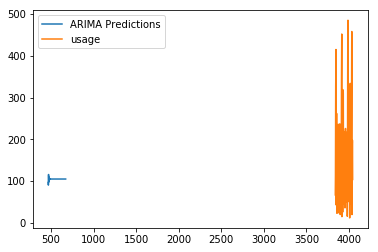

In [72]:
start=len(training_dataMP5)
end=len(training_dataMP5)+len(testing_dataMP5)-1
predMP5=model5.predict(start=start,end=end,typ='levels').rename('ARIMA Predictions')
predMP5.plot(legend=True)
testing_dataMP5['usage'].plot(legend=True)


testing_dataMP5['usage'].mean()
rmseMP5=sqrt(mean_squared_error(predMP5,testing_dataMP5['usage']))
print("Mean Squared Error:", rmseMP5)

### ARIMA Model for Municipality 6

In [52]:
model6=sm.tsa.arima.ARIMA(training_dataMP6['usage'],order=(2,1,2))
model6=model6.fit()
model6.summary()

D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
D:\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-in

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  usage   No. Observations:                  469
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -3073.254
Date:                Fri, 13 May 2022   AIC                           6156.507
Time:                        17:23:25   BIC                           6177.250
Sample:                             0   HQIC                          6164.670
                                - 469                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.4484      0.052     27.708      0.000       1.346       1.551
ar.L2         -0.7968      0.041    -19.275      0.000      -0.878      -0.716
ma.L1         -1.4714      0.072    -20.417      0.000      -1.613      -1.330
ma.L2          0.6019      0.068      8.789      0.000       0.468       0.736
sigma2      2.952e+04   1414.432     20.868      0.000    2.67e+04    3.23e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):               866.87
Prob(Q):                              0.83   Prob(JB):                         0.00
Heteroskedasticity (H):               1.93   Skew:                            -1.63
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.82
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Mean Squared Error: 283.0777378814435


D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:843: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  data=self.data,


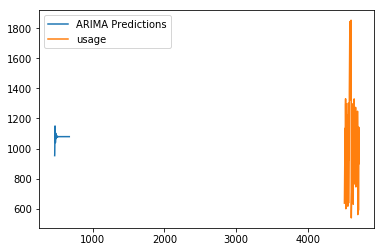

In [80]:
start=len(training_dataMP6)
end=len(training_dataMP6)+len(testing_dataMP6)-1
predMP6=model6.predict(start=start,end=end,typ='levels').rename('ARIMA Predictions')
predMP6.plot(legend=True)
testing_dataMP6['usage'].plot(legend=True)

testing_dataMP6['usage'].mean()
rmseMP6=sqrt(mean_squared_error(predMP6,testing_dataMP6['usage']))
print("Mean Squared Error:", rmseMP6)

### ARIMA Model for Municipality 7

In [53]:
model7=sm.tsa.arima.ARIMA(training_dataMP7['usage'],order=(2,1,2))
model7=model7.fit()
model7.summary()

D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
D:\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-in

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  usage   No. Observations:                  469
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -3133.824
Date:                Fri, 13 May 2022   AIC                           6277.648
Time:                        17:23:28   BIC                           6298.390
Sample:                             0   HQIC                          6285.810
                                - 469                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3544      0.045      7.868      0.000       0.266       0.443
ar.L2         -0.8895      0.041    -21.911      0.000      -0.969      -0.810
ma.L1         -0.1878      0.042     -4.475      0.000      -0.270      -0.106
ma.L2          0.8915      0.039     22.912      0.000       0.815       0.968
sigma2      3.828e+04   1719.562     22.259      0.000    3.49e+04    4.16e+04
===================================================================================
Ljung-Box (L1) (Q):                   1.40   Jarque-Bera (JB):               457.09
Prob(Q):                              0.24   Prob(JB):                         0.00
Heteroskedasticity (H):               1.45   Skew:                            -1.43
Prob(H) (two-sided):                  0.02   Kurtosis:                         6.90
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Mean Squared Error: 275.6774586046129


D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:843: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  data=self.data,


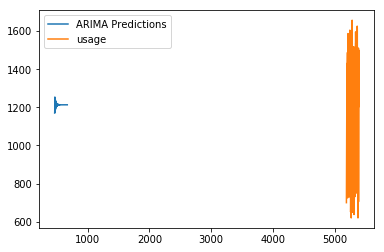

In [73]:
start=len(training_dataMP7)
end=len(training_dataMP7)+len(testing_dataMP7)-1
predMP7=model7.predict(start=start,end=end,typ='levels').rename('ARIMA Predictions')
predMP7.plot(legend=True)
testing_dataMP7['usage'].plot(legend=True)


testing_dataMP7['usage'].mean()
rmseMP7=sqrt(mean_squared_error(predMP7,testing_dataMP7['usage']))
print("Mean Squared Error:", rmseMP7)

##### ARIMA Model Training for Municipality 8

In [54]:
model8=sm.tsa.arima.ARIMA(training_dataMP8['usage'],order=(2,1,2))
model8=model8.fit()
model8.summary()

D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
D:\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-in

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  usage   No. Observations:                  469
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -3106.889
Date:                Fri, 13 May 2022   AIC                           6223.777
Time:                        17:23:31   BIC                           6244.519
Sample:                             0   HQIC                          6231.939
                                - 469                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.1915      0.197      6.056      0.000       0.806       1.577
ar.L2         -0.4482      0.138     -3.237      0.001      -0.720      -0.177
ma.L1         -1.2667      1.800     -0.704      0.481      -4.794       2.260
ma.L2          0.2668      0.507      0.526      0.599      -0.728       1.261
sigma2      3.381e+04   6.09e+04      0.555      0.579   -8.55e+04    1.53e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               446.47
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):               1.00   Skew:                            -1.55
Prob(H) (two-sided):                  0.99   Kurtosis:                         6.65
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Mean Squared Error: 296.5290917028968


D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:843: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  data=self.data,


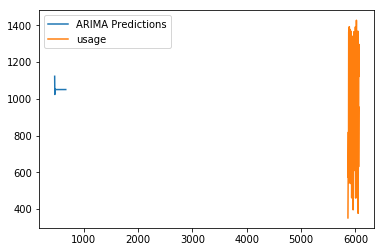

In [74]:
start=len(training_dataMP8)
end=len(training_dataMP8)+len(testing_dataMP8)-1
predMP8=model8.predict(start=start,end=end,typ='levels').rename('ARIMA Predictions')
predMP8.plot(legend=True)
testing_dataMP8['usage'].plot(legend=True)


testing_dataMP8['usage'].mean()
rmseMP8=sqrt(mean_squared_error(predMP8,testing_dataMP8['usage']))
print("Mean Squared Error:", rmseMP8)

### ARIMA Model for Municipality 9

In [55]:
model9=sm.tsa.arima.ARIMA(training_dataMP9['usage'],order=(2,1,2))
model9=model9.fit()
model9.summary()

D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
D:\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-in

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  usage   No. Observations:                  469
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -2917.208
Date:                Fri, 13 May 2022   AIC                           5844.416
Time:                        17:23:34   BIC                           5865.159
Sample:                             0   HQIC                          5852.578
                                - 469                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3342      0.053      6.277      0.000       0.230       0.439
ar.L2         -0.8749      0.047    -18.737      0.000      -0.966      -0.783
ma.L1         -0.1710      0.053     -3.237      0.001      -0.275      -0.067
ma.L2          0.8747      0.045     19.227      0.000       0.786       0.964
sigma2      1.517e+04    616.730     24.603      0.000     1.4e+04    1.64e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.68   Jarque-Bera (JB):               814.03
Prob(Q):                              0.41   Prob(JB):                         0.00
Heteroskedasticity (H):               1.45   Skew:                            -1.73
Prob(H) (two-sided):                  0.02   Kurtosis:                         8.45
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Mean Squared Error: 173.96869197082978


D:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:843: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  data=self.data,


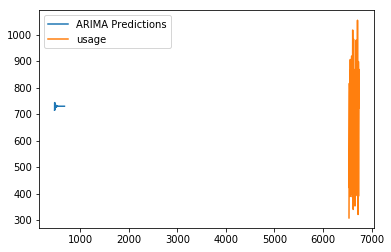

In [75]:
start=len(training_dataMP9)
end=len(training_dataMP9)+len(testing_dataMP9)-1
predMP9=model9.predict(start=start,end=end,typ='levels').rename('ARIMA Predictions')
predMP9.plot(legend=True)
testing_dataMP9['usage'].plot(legend=True)


testing_dataMP9['usage'].mean()
rmseMP9=sqrt(mean_squared_error(predMP9,testing_dataMP9['usage']))
print("Mean Squared Error:", rmseMP9)